# 1. Mercado de Capitales 

En esta sección se estudiarán conceptos básicos del mercado de valores colombiano y repasaremos algunos conceptos de estadísticas que necesitaremos

Descarga las diapositivas [Descargar: Mercado y Estadísticas básicas](1_Mercado_Estadísitica.pdf)


## 1. Extracción de datos

Para esta primera práctica, tomaremos los datos de algunas acciones que se encuentran listadas en el Mercado Colombiano y que tienen reporte en Yahoo finance. 

Visite el sitio de [Yahoo Finance](https://finance.yahoo.com)

Activos: 'ECOPETROL.CL', 'ISA.CL', 'NUTRESA.CL', 'GRUPOARGOS.CL'

Preparamos las librerías necesarias:

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
import statsmodels.api as sm

Descargamos y leemos los datos

In [8]:
tickers = ['ECOPETROL.CL', 'ISA.CL', 'NUTRESA.CL', 'GRUPOARGOS.CL']
start = '2010-01-01'
end = '2025-12-31'

# 1. Extracción y Limpieza (similar al de la función)
data_for_plot = yf.download(tickers, start=start, end=end)

# Handle MultiIndex for 'Adj Close' when multiple tickers are present
if isinstance(data_for_plot.columns, pd.MultiIndex):
    data_for_plot = data_for_plot.xs('Close', level=0, axis=1)
else:
    data_for_plot = data_for_plot['Close']

# Manejo de iliquidez: Forward fill y eliminación de NaNs iniciales
data_for_plot = data_for_plot.ffill().dropna()

[*********************100%***********************]  4 of 4 completed


## 2. Análisis exploratorio de las series de tiempo

Analizar visulamente el comportamiento de las series. 

¿Que podemos observar?

- Tendencias
- Cambios en la varianza
- Ciclos 

En resumen: Falta de Homocedasticidad



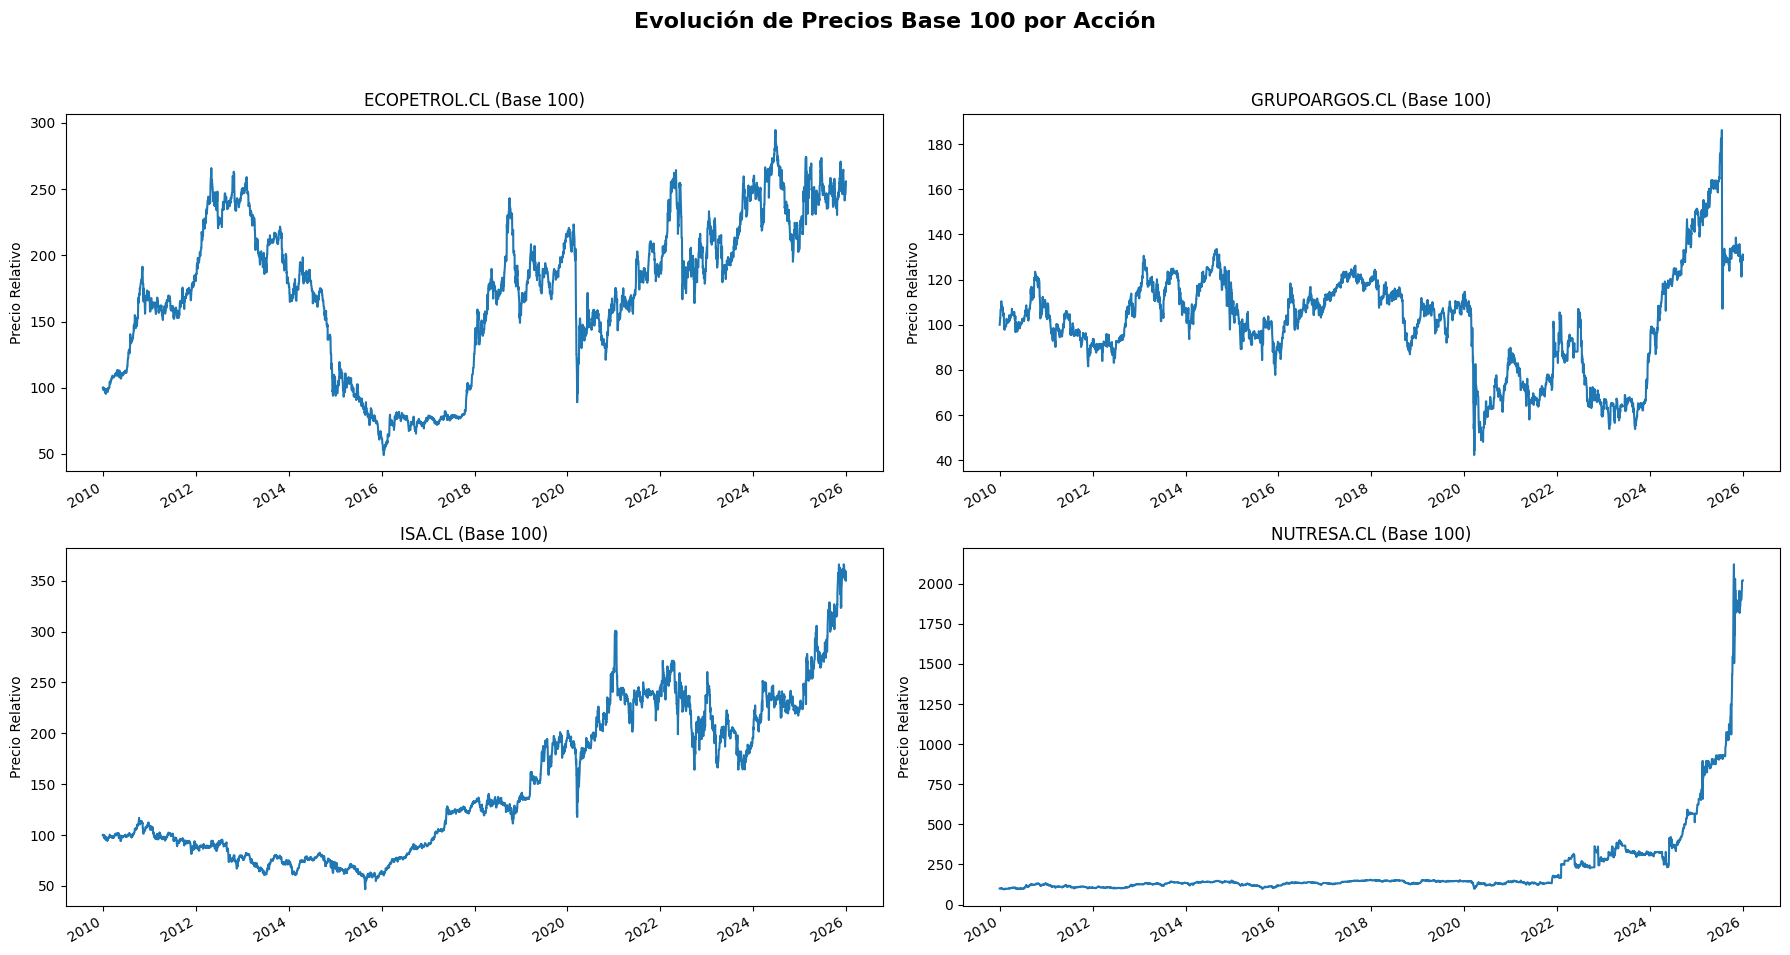

In [9]:
n_tickers = len(data_for_plot.columns)
n_cols = 2
n_rows = (n_tickers + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
fig.suptitle('Evolución de Precios Base 100 por Acción', fontsize=16, fontweight='bold')

axes = axes.flatten() # Flatten the axes array for easy iteration

for i, ticker in enumerate(data_for_plot.columns):
    (data_for_plot[ticker] / data_for_plot[ticker].iloc[0] * 100).plot(ax=axes[i])
    axes[i].set_title(f'{ticker} (Base 100)')
    axes[i].set_ylabel('Precio Relativo')
    axes[i].set_xlabel('') # Remove x-label from individual plots for cleaner look

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 3. Aplicación de retornos logarítmicos

En la práctica general se trabaja desde los retornos de la serie y no desde el precio directo. 

¿qué observamos sobre los rendimientos?

- No tendencia
- Problemas en varianza

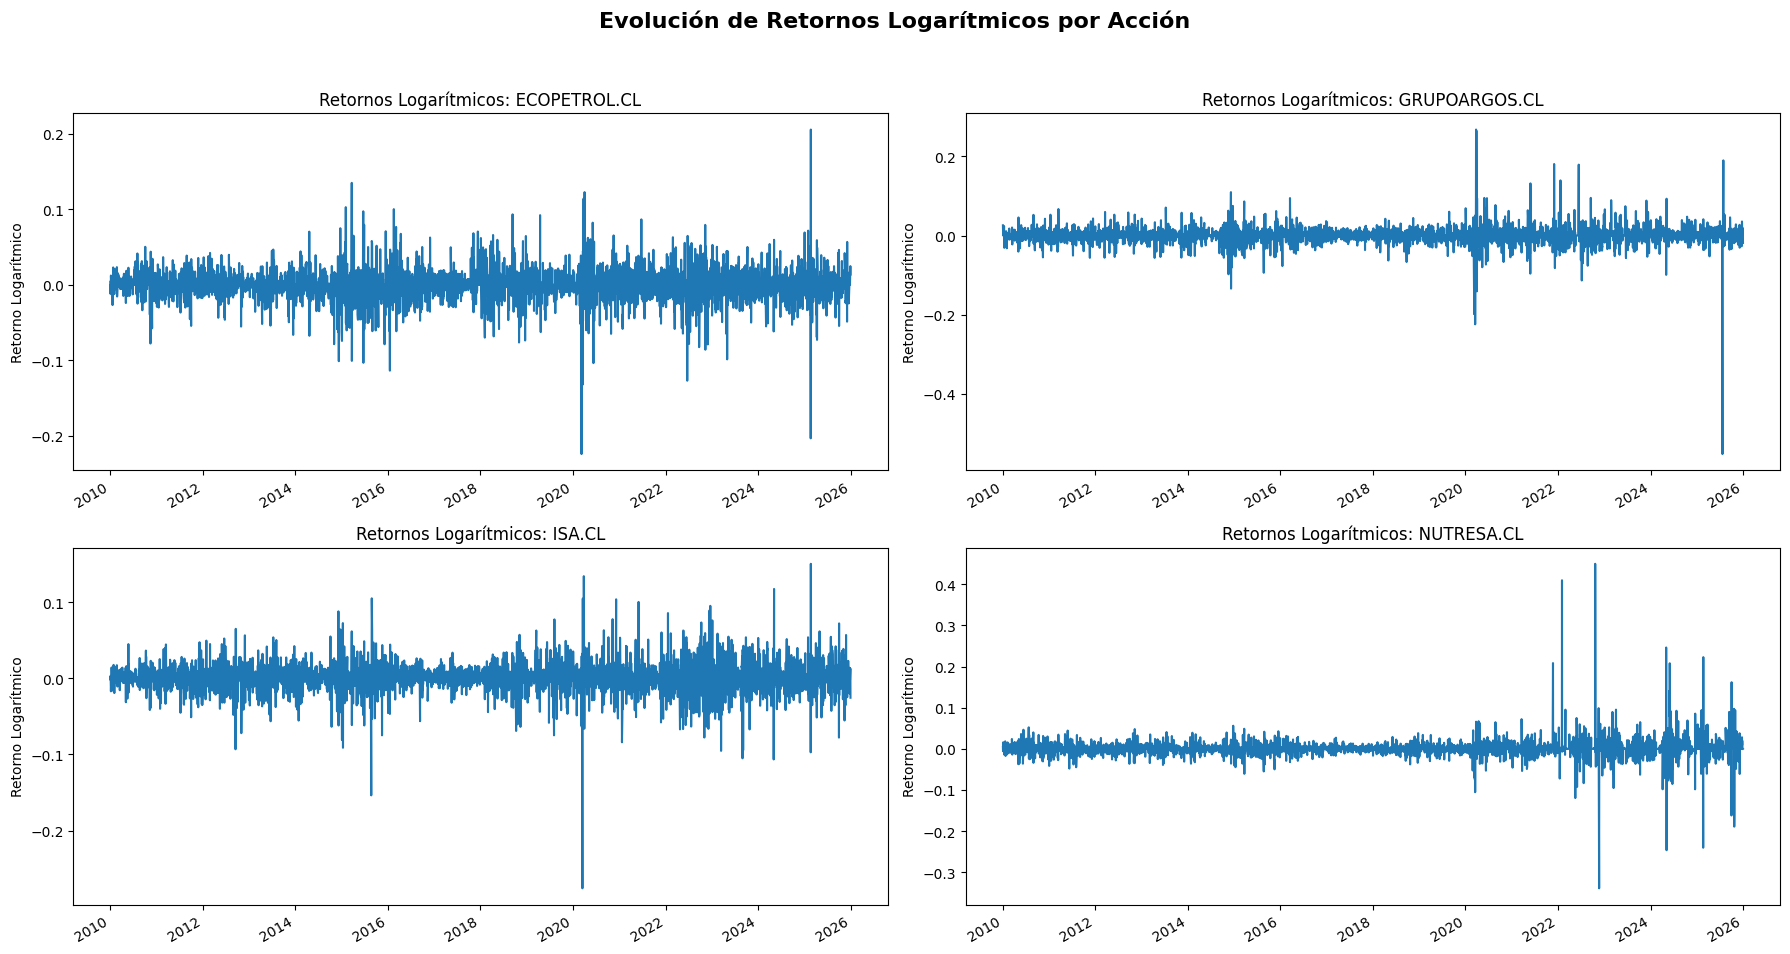

In [10]:
# Calculate logarithmic returns
log_returns = np.log(data_for_plot / data_for_plot.shift(1)).dropna()

n_tickers = len(log_returns.columns)
n_cols = 2
n_rows = (n_tickers + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
fig.suptitle('Evolución de Retornos Logarítmicos por Acción', fontsize=16, fontweight='bold')

axes = axes.flatten() # Flatten the axes array for easy iteration

for i, ticker in enumerate(log_returns.columns):
    log_returns[ticker].plot(ax=axes[i])
    axes[i].set_title(f'Retornos Logarítmicos: {ticker}')
    axes[i].set_ylabel('Retorno Logarítmico')
    axes[i].set_xlabel('') # Remove x-label from individual plots for cleaner look

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4. Análisis de la distribución de los rendimientos

Uno de los principales supuestos clásicos de pronóstico es que los rendimientos provienen de la distribución normal y muchos de los modelos de pronóstico asumen esto. ¿que podemos observar?


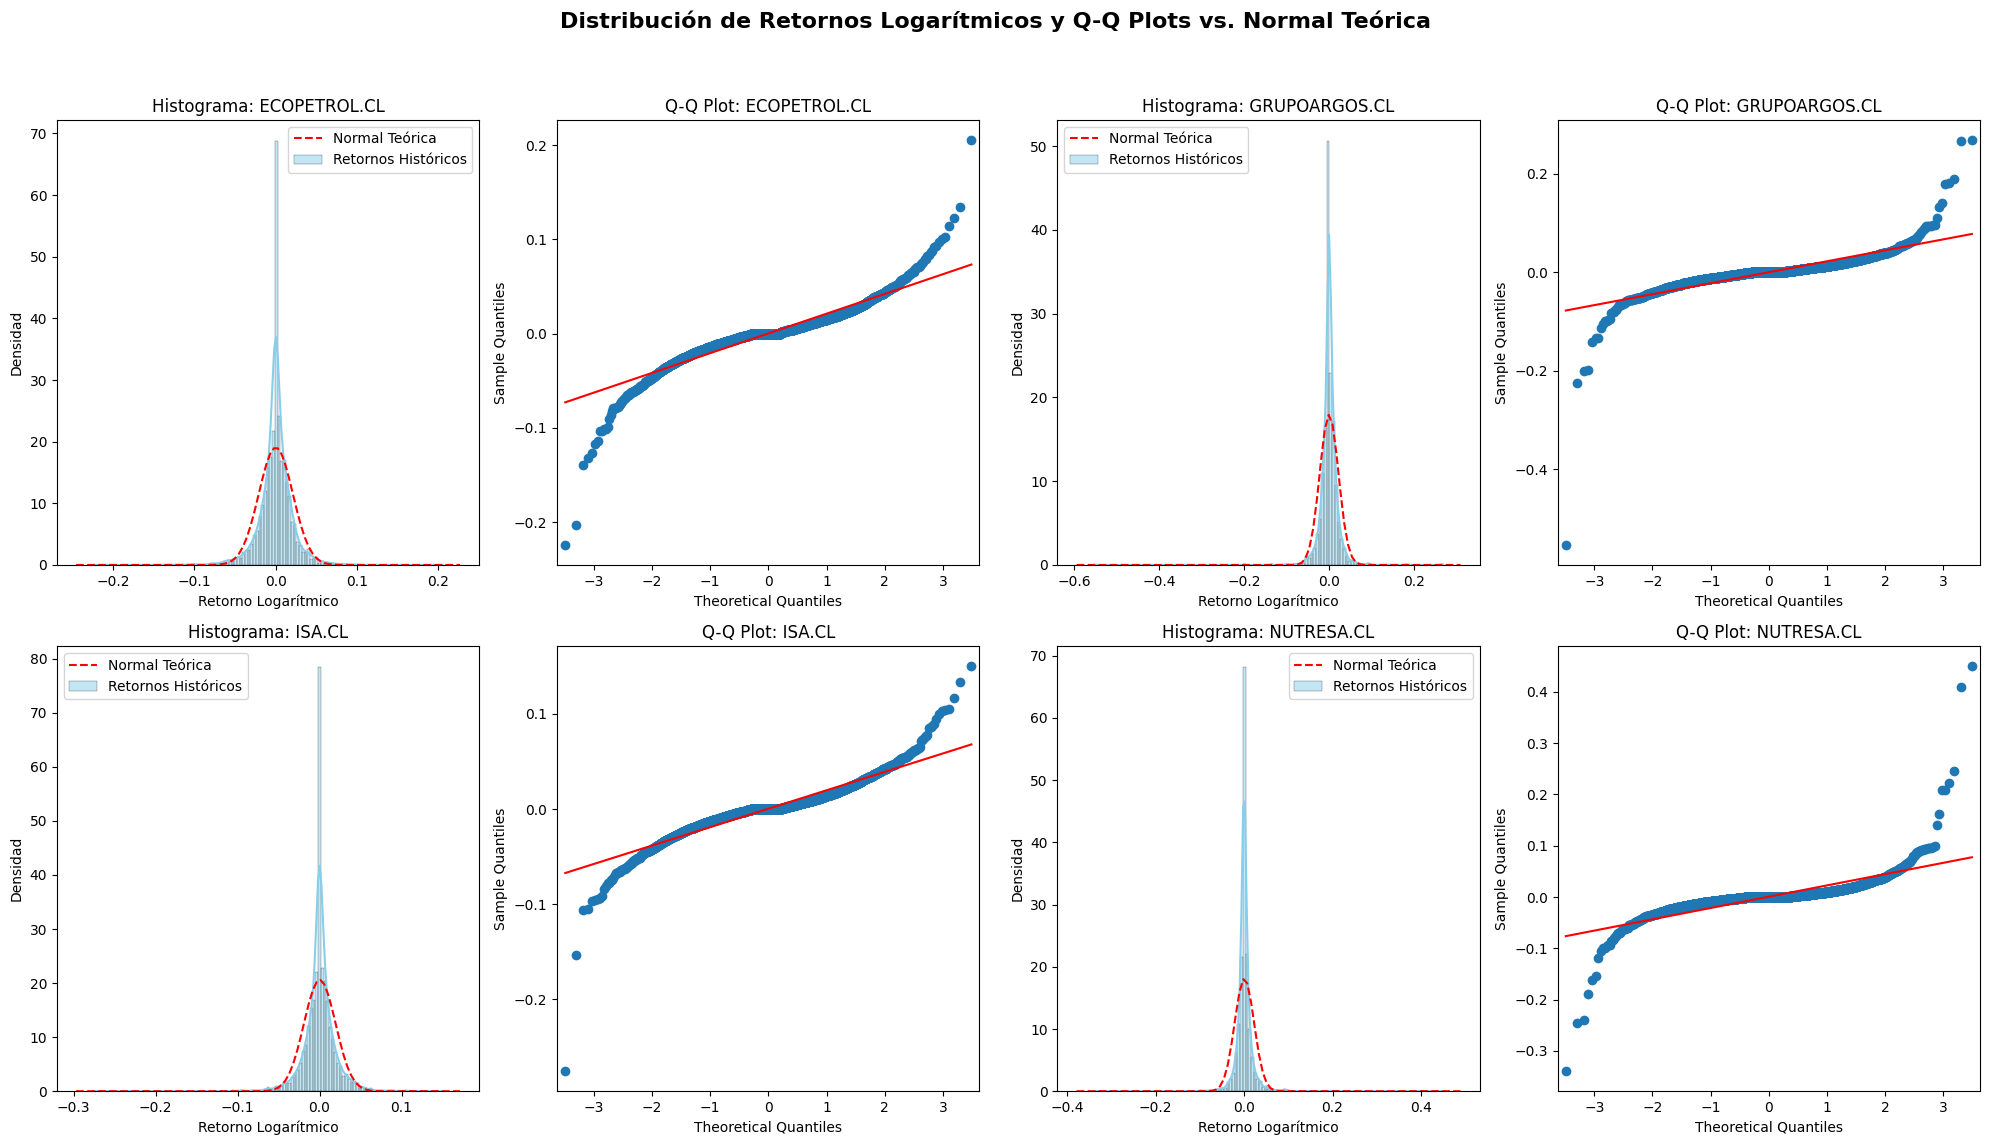

In [11]:
n_tickers = len(log_returns.columns)
plots_per_ticker = 2 # Histogram and Q-Q plot
n_stocks_per_row = 2
n_cols_display = n_stocks_per_row * plots_per_ticker # 2 stocks * 2 plots/stock = 4 columns
n_rows_display = (n_tickers + n_stocks_per_row - 1) // n_stocks_per_row

fig, axes = plt.subplots(n_rows_display, n_cols_display, figsize=(20, n_rows_display * 6))
fig.suptitle('Distribución de Retornos Logarítmicos y Q-Q Plots vs. Normal Teórica', fontsize=16, fontweight='bold')

axes = axes.flatten() # Flatten the axes array for easy iteration

for i, ticker in enumerate(log_returns.columns):
    # Plot Histogram
    ax_hist = axes[i * plots_per_ticker]
    sns.histplot(log_returns[ticker], kde=True, stat="density", ax=ax_hist, color='skyblue', label='Retornos Históricos')

    # Superponer Normal teórica
    mu, std = log_returns[ticker].mean(), log_returns[ticker].std()
    xmin, xmax = ax_hist.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    ax_hist.plot(x, stats.norm.pdf(x, mu, std), 'r--', label='Normal Teórica')

    ax_hist.set_title(f'Histograma: {ticker}')
    ax_hist.set_ylabel('Densidad')
    ax_hist.set_xlabel('Retorno Logarítmico')
    ax_hist.legend()

    # Plot Q-Q Plot
    ax_qq = axes[i * plots_per_ticker + 1]
    sm.qqplot(log_returns[ticker], line='s', ax=ax_qq)
    ax_qq.set_title(f'Q-Q Plot: {ticker}')

# Hide any unused subplots (if n_tickers is odd and doesn't fill the last row completely)
for j in range(n_tickers * plots_per_ticker, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 5. Análisis descriptivo de la serie

Veamos el comportamientos de algunos estadísticos de orden, sobre los rendiemintos de las acciones. ¿son distirbuciones simétricas?

In [12]:
print("Descriptive Statistics of Logarithmic Returns:")
print(log_returns.describe())

Descriptive Statistics of Logarithmic Returns:
Ticker  ECOPETROL.CL  GRUPOARGOS.CL       ISA.CL   NUTRESA.CL
count    4146.000000    4146.000000  4146.000000  4146.000000
mean        0.000226       0.000061     0.000302     0.000725
std         0.020946       0.022237     0.019382     0.022031
min        -0.223987      -0.552603    -0.275626    -0.339040
25%        -0.007634      -0.006995    -0.006920    -0.004292
50%         0.000000       0.000000     0.000000     0.000000
75%         0.009185       0.007680     0.007722     0.004753
max         0.205405       0.268117     0.150118     0.449894


In [13]:
correlation_matrix = log_returns.corr()
print("Matriz de Correlación de Retornos Logarítmicos:")
print(correlation_matrix)

Matriz de Correlación de Retornos Logarítmicos:
Ticker         ECOPETROL.CL  GRUPOARGOS.CL    ISA.CL  NUTRESA.CL
Ticker                                                          
ECOPETROL.CL       1.000000       0.293710  0.321416    0.159410
GRUPOARGOS.CL      0.293710       1.000000  0.349053    0.144938
ISA.CL             0.321416       0.349053  1.000000    0.166205
NUTRESA.CL         0.159410       0.144938  0.166205    1.000000


## 6. Correlación de los rendimientos de los activos 

Existen ciertas dependencias entre los activos de un mercado. ¿que podríamos interpretar? ¿implicaría algún riesgo al inversionista?


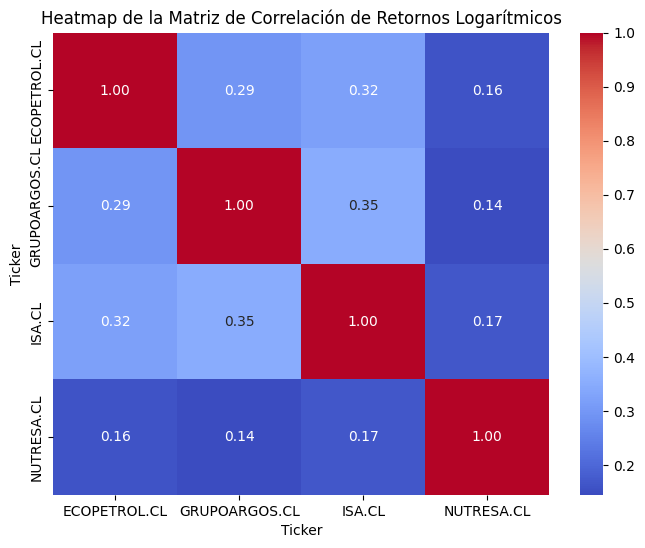

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap de la Matriz de Correlación de Retornos Logarítmicos')
plt.show()

## 7. Desviación estandar como primera medida de riesgo de los activos

Llamaremos volatilidad a las posibles medidas de riesgo que se generen con respecto al valor esperado. la primera forma de medir es la desviación estandar. 

**Nota aclaratoria:** la volatilidad de un activo no es una variable directamente observable, siempre requerirá de algún calculo para obtenerla. 

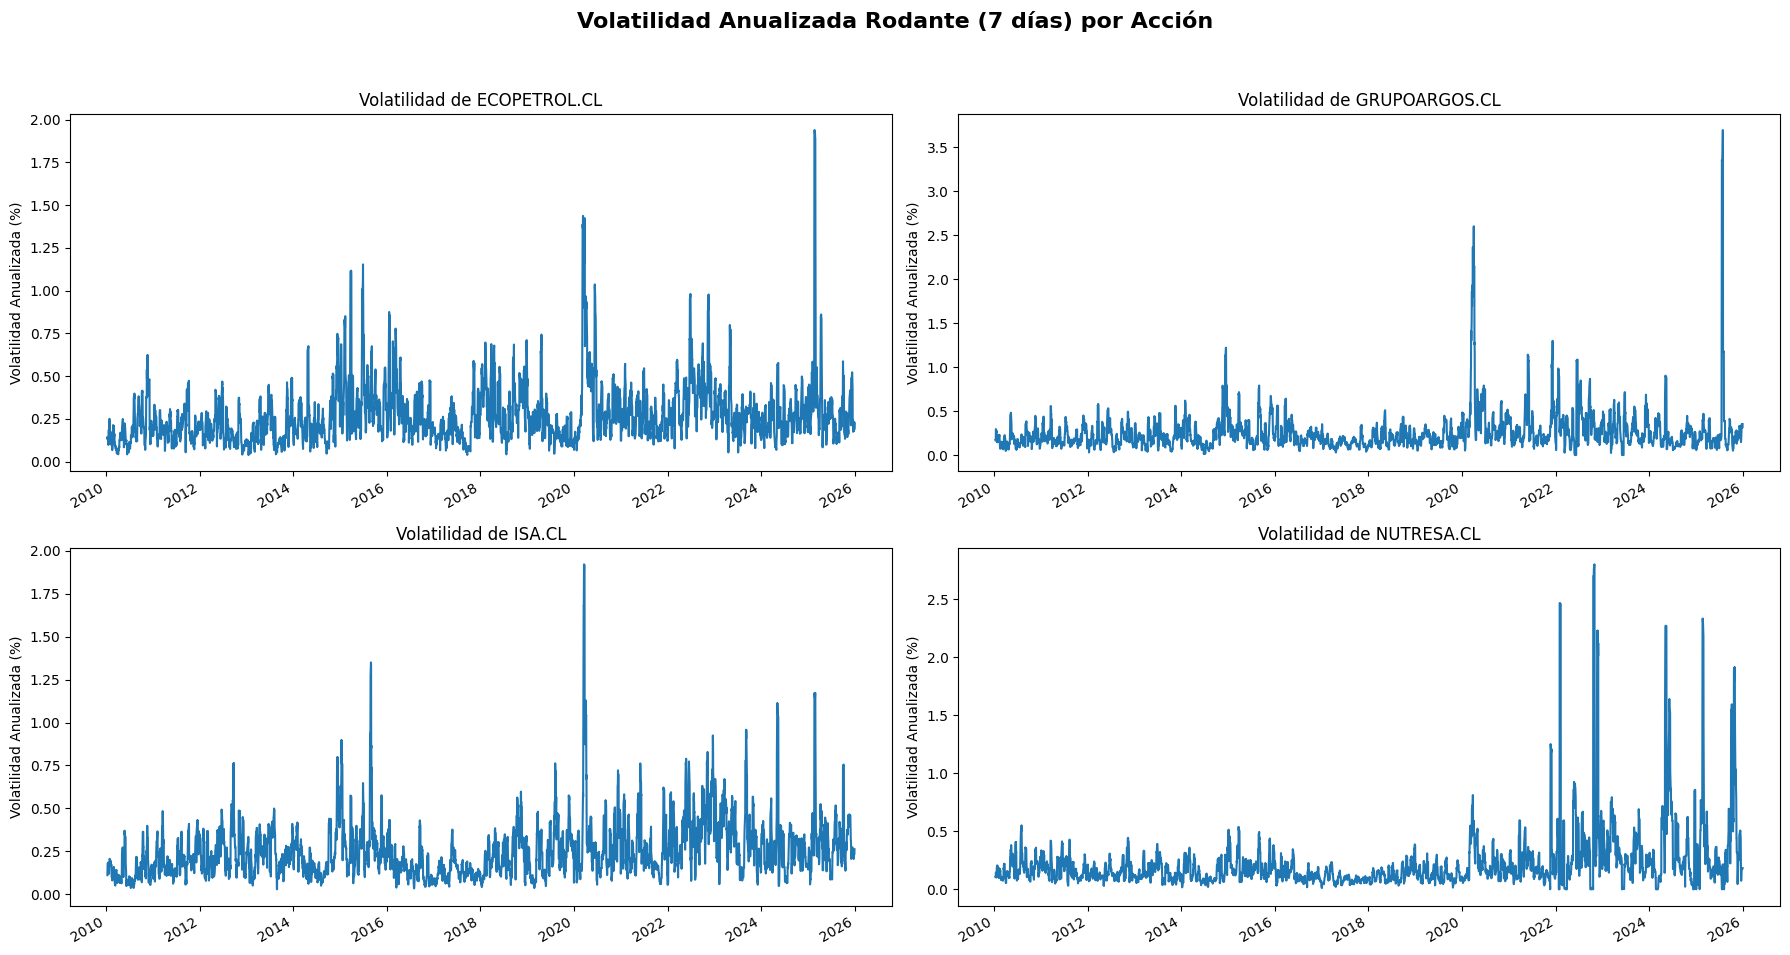

In [15]:
rolling_volatility = log_returns.rolling(window=7).std().mul(np.sqrt(252))

n_tickers = len(rolling_volatility.columns)
n_cols = 2
n_rows = (n_tickers + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
fig.suptitle('Volatilidad Anualizada Rodante (7 días) por Acción', fontsize=16, fontweight='bold')

axes = axes.flatten() # Flatten the axes array for easy iteration

for i, ticker in enumerate(rolling_volatility.columns):
    rolling_volatility[ticker].plot(ax=axes[i])
    axes[i].set_title(f'Volatilidad de {ticker}')
    axes[i].set_ylabel('Volatilidad Anualizada (%)')
    axes[i].set_xlabel('') # Remove x-label from individual plots for cleaner look

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 8. Covarianza de las volatilidades

La covarianza es la utilizada para la construcción del portafolio, ya que es una forma mas sencilla de calcular las variacions conjunta de los activos que componen la cartera. 

Matriz de Covarianza de Retornos Logarítmicos:
Ticker         ECOPETROL.CL  GRUPOARGOS.CL    ISA.CL  NUTRESA.CL
Ticker                                                          
ECOPETROL.CL       0.000439       0.000137  0.000130    0.000074
GRUPOARGOS.CL      0.000137       0.000494  0.000150    0.000071
ISA.CL             0.000130       0.000150  0.000376    0.000071
NUTRESA.CL         0.000074       0.000071  0.000071    0.000485


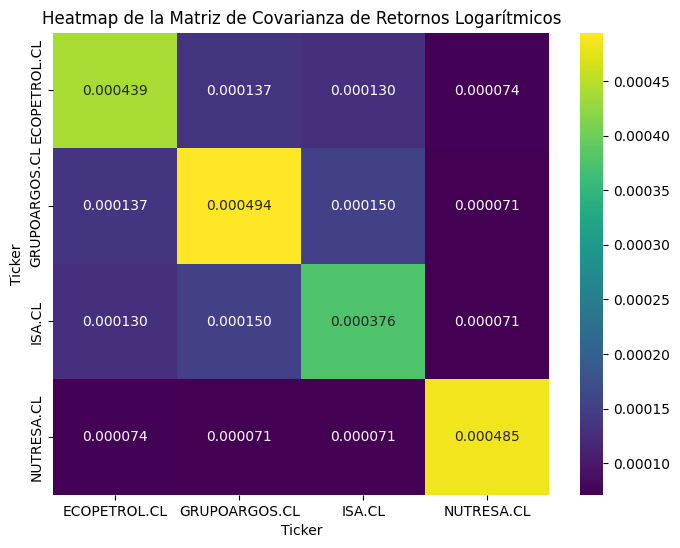

In [16]:

# Ensure log_returns is defined (re-calculating it here for robustness, though it should be defined from cell e681b64f)
log_returns = np.log(data_for_plot / data_for_plot.shift(1)).dropna()

covariance_matrix = log_returns.cov()
print("Matriz de Covarianza de Retornos Logarítmicos:")
print(covariance_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(covariance_matrix, annot=True, cmap='viridis', fmt=".6f")
plt.title('Heatmap de la Matriz de Covarianza de Retornos Logarítmicos')
plt.show()